In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
from apatools.lm import lm, lm_report, mlm_icc
from apatools.format import format_p, get_stars, format_r
import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
# https://github.com/statsmodels/statsmodels/issues/6210
def icc(r):
    '''the Intraclass Correlation Coefficient (ICC)'''
    return (r.cov_re / (r.cov_re + r.scale)).values[0, 0]

def lr_test(formula, data, groups): # if p<0.05 then use random effects
    '''likelihood ratio test of random-effects'''
    null_model = smf.mixedlm(formula, data=data, groups=groups, missing='drop').fit(reml=False)
    ols_model = smf.ols(formula, data=data).fit()
    lrt = np.abs(null_model.llf - ols_model.llf) * 2
    p = stats.chi2.sf(lrt, 1)
    return (lrt, p)

def mixedlm_r2(m):
    # Fixed effects variance
    print(type(m))
    X = m.model.exog
    beta = m.fe_params.values
    fixed_pred = X @ beta
    var_fixed = np.var(fixed_pred)

    # Random effects variance
    var_random = 0.0

    # Add group-level variance ONLY if it exists
    if m.cov_re.shape[0] > 0:
        var_random += np.sum(np.diag(m.cov_re))

    # Add variance components (region, city, etc.)
    if hasattr(m, "vcomp") and m.vcomp is not None:
        var_random += sum(m.vcomp)

    # Residual variance
    var_resid = m.scale

    # R²
    r2_m = var_fixed / (var_fixed + var_random + var_resid)
    r2_c = (var_fixed + var_random) / (var_fixed + var_random + var_resid)
    # Marginal R² (r2_m) → variance explained by fixed effects only
    # Conditional R² (r2_c) → variance explained by fixed + random effects

    return r2_m, r2_c

# https://stats.stackexchange.com/questions/401584/calculating-r2-for-a-linear-mixed-model-in-python
def metrics_mlm(r):
    r_sq_m, r_sq_c = mixedlm_r2(r)
    df_model = r.df_modelwc - 1
    df_resid = max(r.df_resid, r.nobs - df_model)
    fitted = r.fittedvalues
    observed = r.resid + fitted
    SSe = np.sum(r.resid ** 2)
    SSt = np.sum((observed - np.mean(observed)) ** 2)
    r_sq = 1 - SSe / SSt
    r_sq_adj = 1 - (1 - r_sq) * r.nobs / df_resid
    f_stat = (r_sq_c / df_model) / ((1 - r_sq_c) / df_resid)
    fp_value = stats.f.sf(f_stat, df_model, df_resid)
    return {'r_sq' : r_sq, 'r_sq_adj' : r_sq_adj,
            'r_sq_m' : r_sq_m, 'r_sq_c' : r_sq_c,
            'df_model' : df_model, 'df_resid' : df_resid,
            'f_stat' : f_stat, 'f_pvalue' : fp_value,
            'aic' : r.aic, 'bic': r.bic, 'obs' : r.nobs}

def report_mlm(r, i):
    params = r.summary().tables[1].rename(
                columns={
                    "Coef.": "coef",
                    "P>|z|": "p-value",
                    "Std.Err.": "se",
                    "[0.025": "cil",
                    "0.975]": "cir",
                }
            )
    params["sig"] = [get_stars(float(c)) if len(c) else c for c in params["p-value"]]
    params["p-value"] = [format_p(float(c), use_letter=False,
                                  no_equals=True,
                                  keep_spaces=False) if len(c) else c for c in params["p-value"]]
    params['model'] = ''
    params.loc[params.index[0], 'model'] = i
    return params

def format_v(r):
    if not np.isfinite(r):
        r = 'inf'
    elif abs(r) >= 0.999:
        r = '.99'
    else:
        r = f"{'-' if r < 0.0 else ''}"+f"{abs(r):.2f}"[1:]
    return r

In [ ]:
base_dir = './'
results_dir = os.path.join(base_dir, "results")
data_dir = os.path.join(base_dir, "data")

In [4]:
df = pd.read_csv(os.path.join(results_dir, "data.csv"), index_col=0)
print(f"n={len(df)}")
df.head()

n=36109


,mean_shared_capacity,lifetime,mean_degree,city,region,country,latitude,longitude,log_mean_degree,log_lifetime,log_mean_shared_capacity,gdp_cap,gini,hdi,log_gdp_cap
0,1.292802e+07,42,15.750000,Nürnberg,Bavaria,DE,49.4542,11.0775,1.224015,1.633468,7.111532,43961.056336,32.10,0.95675,4.643078
1,1.000000e+05,98,2.000000,NaN,NaN,NaN,NaN,NaN,0.477121,1.995635,5.000004,NaN,NaN,NaN,NaN
2,2.218966e+05,145,1.724138,NaN,NaN,NaN,NaN,NaN,0.435229,2.164353,5.346153,NaN,NaN,NaN,NaN
3,3.939878e+07,509,34.150000,Helsinki,Uusimaa,FI,60.1695,24.9354,1.545925,2.707570,7.595483,45550.955048,27.56,0.94750,4.658507
4,3.077402e+06,1596,23.651613,Strasbourg,Grand Est,FR,48.5839,7.7455,1.391845,3.203305,6.488184,38126.602922,31.28,0.91500,4.581240


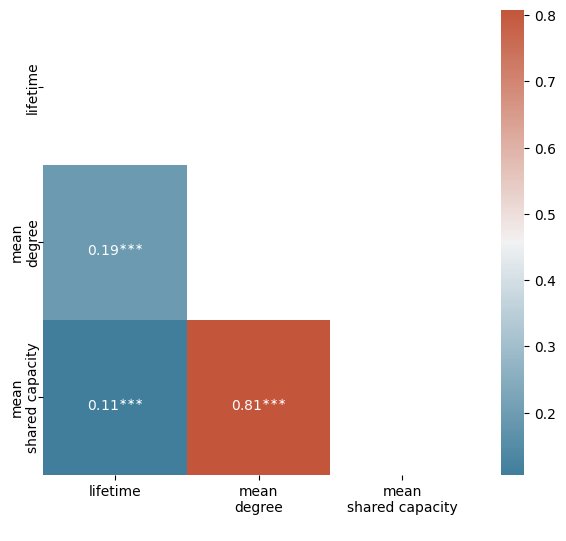

In [68]:
d = df.copy()[["lifetime", "mean_degree", "mean_shared_capacity"]].rename(columns={
    "lifetime": "lifetime",
    "mean_degree": "mean\ndegree\n",
    "mean_shared_capacity": "mean\nshared capacity\n"})
c = d.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").statistic)
p = d.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").pvalue)
a = c.copy().astype(str)
for i in a.keys():
    for j in a[i].keys():
        a.loc[i, j] = f"{c[i][j]:.2f}$^{{{get_stars(p[i][j])}}}$".replace('*', '{\\ast}')
cmap = sns.diverging_palette(230, 20, n=256, as_cmap=True)
mask = np.triu(np.ones_like(c, dtype=bool))
fig, ax = plt.subplots(figsize=(6, 5.5))
ax = sns.heatmap(c, cmap=cmap, mask=mask, annot_kws={'va':'top'}, fmt='', 
                 robust=False, ax=ax, cbar=True, annot=a) #cmap="YlGnBu"
ax.set_yticklabels(labels=ax.get_yticklabels(), ha='center', rotation=90)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig03.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format='pdf',
    )


mean_shared_capacity == 0: 0 0.0
mean_degree == 0: 0 0.0
lifetime == 0: 628 0.017391785981334295


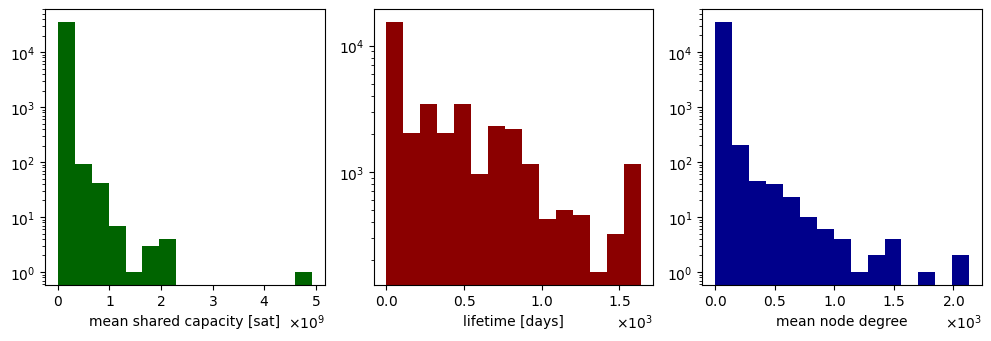

In [69]:
d = df.copy()
print("mean_shared_capacity == 0:", 
      (d['mean_shared_capacity'] == 0).sum(), 
      (d['mean_shared_capacity'] == 0).sum()/len(d))

print("mean_degree == 0:", 
      (d['mean_degree'] == 0).sum(), 
      (d['mean_degree'] == 0).sum()/len(d))

print("lifetime == 0:", 
      (d['lifetime'] == 0).sum(), 
      (d['lifetime'] == 0).sum()/len(d))

fig = plt.figure(figsize=(10, 3.5))
ax_left = fig.add_subplot(1, 3, 1)
d.mean_shared_capacity.hist(ax=ax_left, bins=15, label="mean shared capacity", 
                            log=True, color='darkgreen', grid=False)
# ax_left.legend(loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_left.xaxis.set_major_formatter(xfmt)
ax_left.set_xlabel("mean shared capacity [sat]")

ax_center = fig.add_subplot(1, 3, 2)
d.lifetime.hist(ax=ax_center, bins=15, label="lifetime", 
                log=True, color='darkred', grid=False)
# ax_center.legend(loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_center.xaxis.set_major_formatter(xfmt)
ax_center.set_xlabel("lifetime [days]")

ax_right= fig.add_subplot(1, 3, 3)
d.mean_degree.hist(ax=ax_right, bins=15, label="mean node degree", 
                   log=True, color='darkblue', grid=False)
# ax_right.legend(loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_right.xaxis.set_major_formatter(xfmt)
ax_right.set_xlabel("mean node degree")

fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig02.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format='pdf',
    )

In [300]:
results = {}

In [302]:
# H1 Lifetime → Capacity (RLM)
d = df.copy()
d = d[d['lifetime'] > 0]
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = False,
                                    standardized = True,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0].iloc[0]
results['H1(RLM)full'] = r
print(r['model'])
f"β={r['coef']:.2f}{r['sig']}, 95%CI [{r['cil']:.2f}, {r['cir']:.2f}]"

N=35481
formula: log_mean_shared_capacity ~ log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x00000193EA8EC650>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                35481
Model:                                  RLM   Df Residuals:                    35480
Method:                                IRLS   Df Model:                            0
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Wed, 18 Mar 2026                                         
Time:                              16:29:49                                         
No. Iterations:                           7                         

'β=0.11***, 95%CI [0.10, 0.12]'

In [316]:
# H1 Lifetime → Capacity (RLM)
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = False,
                                    standardized = True,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0].iloc[0]
results['H1(RLM)country'] = r
print(r['model'])
f"β={r['coef']:.2f}{r['sig']}, 95%CI [{r['cil']:.2f}, {r['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x00000193EB1F82F0>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7916
Method:                                IRLS   Df Model:                            0
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Wed, 18 Mar 2026                                         
Time:                              16:36:48                                         
No. Iterations:                           7                          

'β=0.02*, 95%CI [0.00, 0.05]'

In [34]:
# H1 Lifetime → Capacity (MLM)
f = "log_mean_shared_capacity ~ log_lifetime"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
r = metrics_mlm(m)
#results['H1(MLM)country'] = r
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

<class 'statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper'>


KeyError: 'fp_value'

In [35]:
# H1 Lifetime → Capacity (RLM)
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'rlm',
                                    verbose = False,
                                    constant = False,
                                    standardized = True,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0].iloc[0]
f = "log_mean_shared_capacity ~ log_lifetime"
vc = {"region": "0 + C(region)"}
ml = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)

def r_sq(results):
    """
    Calculating/retrieving R²/R²pseudo, R²adj
    for OLS, RLM, GLM from statsmodels fitting results

    https://stats.stackexchange.com/questions/83826/is-a-weighted-r2-in-robust-linear-model-meaningful-for-goodness-of-fit-analys
    https://stats.stackexchange.com/questions/55236/prove-f-test-is-equal-to-t-test-squared
    """
    print(results.k_fe)
    outputs = {}
    nobs = int(results.nobs)
    params = set(results.params.index)
    n_params = getattr(results, "k_fe", len(params)) # k_fe counts only fixed effects in MixedLM
    if "const" in params or "Intercept" in params:
        n_params -= 1 # number of predictors, without intercept
    print(n_params)

    n_pred = len(
        set(results.params.index) - set(["const", "Intercept"])
    )  # number of predictors, without intercept

    resid = getattr(results, "resid", getattr(results, "resid_working", None))

    print(n_pred, results.params.index)
    df_model = max(int(results.df_model), n_pred)  # technical correction
    df_resid = max(int(results.df_resid), nobs - df_model)  # technical correction
    fitted = results.fittedvalues
    observed = resid + fitted

    # There is a discussion on proper R2 metric for (weighted) robust regresson
    # see also Rousseeuw, P. J., & Leroy, A. M. (1987) p. 42
    # https://github.com/scikit-learn/scikit-learn/blob/51a765a/sklearn/metrics/regression.py#L370
    # SSe = np.sum(weights * resid ** 2)
    # SSt = np.sum(weights * (observed - np.sum(weights * observed) / np.sum(weights)) ** 2)

    # https://stats.stackexchange.com/a/375752
    # https://web.maths.unsw.edu.au/~adelle/Garvan/Assays/GoodnessOfFit.html
    # SSe = np.sum(weights * resid ** 2)
    # SSt = np.sum(weights * (observed - np.mean(observed)) ** 2)

    M = getattr(results.model, "M", False)  # r_sq_pseudo
    if M and callable(M.rho):
        SSe = np.sum(M.rho(resid))
        SSt = np.sum(M.rho(observed - np.mean(observed)))
        outputs.update({"r_sq_pseudo": 1 - SSe / SSt})

    weights = getattr(results, "weights", 1)
    SSe = np.sum(weights * resid**2)
    SSt = np.sum(weights * (observed - np.mean(observed)) ** 2)

    r_sq = getattr(
        results, "rsquared", getattr(results, "pseudo_rsquared", 1 - SSe / SSt)
    )
    r_sq = r_sq() if callable(r_sq) else r_sq
    # https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLSResults.rsquared_adj.html
    r_sq_adj = getattr(results, "rsquared_adj", 1 - (1 - r_sq) * nobs / df_resid)
    # https://www.slideshare.net/slideshow/multiple-regressionppt-252604177/252604177#8
    f_stat = getattr(
        results, "fvalue", (r_sq / df_model) / ((1 - r_sq) / df_resid)
    )  # (SSt / df_model) / (SSe / df_resid)
    f_pvalue = getattr(
        results, "f_pvalue", stats.f.sf(f_stat, df_model, df_resid)
    )
    outputs.update(
        {
            "r_sq": r_sq,
            "r_sq_adj": r_sq_adj,
            "df_model": df_model,
            "df_resid": df_resid,
            "f_stat": f_stat,
            "f_pvalue": f_pvalue,
        }
    )
    return outputs

r_sq(ml)
lm_report([ml], [metrics_mlm(ml)])

2
1
3 Index(['Intercept', 'log_lifetime', 'Group Var', 'region Var'], dtype='str')


AttributeError: 'MixedLMResults' object has no attribute 'df_model'

In [8]:
from io import StringIO
import statsmodels.api as sm
from itertools import zip_longest
from pandas import read_html, DataFrame

def mlm_report(results, metrics={}, format_pval=True, add_stars=True, decimal=None):
    # R² = .34, R²adj = .34, R²pred = .34, F(1, 416) = 6.71, p = .009

    output = []
    for r, i in zip_longest(results, metrics, fillvalue={}):
        s = []
        if "r_sq" in i:
            s.append(f"R² {format_r(i['r_sq'], use_letter=False)}")
        if "r_sq_adj" in i:
            s.append(f"R²adj {format_r(i['r_sq_adj'], use_letter=False)}")
        if "pred_r_sq" in i:
            s.append(f"R²pred {format_r(i['pred_r_sq'], use_letter=False)}")
        #if 'df_model' in i:
        s.append(
                f"F({i['df_model']}, {i['df_resid']}) = {i['f_stat']:.2f}, {format_p(i['f_pvalue'])}"
            )
        s = ", ".join(s)
        #params = read_html(
        #    StringIO(r.summary().tables[1]), header=0, index_col=0
        #)[0]\
        print(type(r))
        if isinstance(r, sm.regression.mixed_linear_model.MixedLMResultsWrapper):
            params = r.summary().tables[1]
        elif isinstance(r, sm.robust.robust_linear_model.RLMResultsWrapper):
            params = read_html(
            StringIO(r.summary().tables[1].as_html()), header=0, index_col=0
        )[0]

        params = params\
                .rename(
                columns={
                    "Coef.": "coef",
                    "P>|z|": "p-value",
                    "Std.Err.": "se",
                    "[0.025": "cil",
                    "0.975]": "cir",
                }
            )
        print(params)
        if decimal:
            for c in ["coef", "se", "cil", "cir"]:
                params[c] = params[c].round(decimal)

        if add_stars:
            add_stars = add_stars if callable(add_stars) else get_stars
            params["sig"] = [get_stars(c) for c in params["p-value"]]

        if format_pval:
            format_pval = (
                format_pval
                if callable(format_pval)
                else lambda x: format_p(
                    x, use_letter=False, keep_spaces=False, no_equals=True
                )
            )
            params["p-value"] = [format_pval(c) for c in params["p-value"]]
        if "vif" in i:
            params = params.join(i["vif"])
        if len(i):
            params.loc[params.index[0], "model"] = s
        output.append(params)

    return output

lm_report([ml], [metrics_mlm(ml)])



[               coef     se       z p-value    cil    cir    sig  \
 Intercept     5.718  0.073  78.743   0.000  5.576  5.861  0.000   
 log_lifetime  0.099  0.021   4.682   0.000  0.058  0.141  0.000   
 Group Var     0.105  0.024                                        
 
                                                           model  
 Intercept     R² = .08, R²adj = .08, F(2, 7915) = 313.97, p ...  
 log_lifetime                                                NaN  
 Group Var                                                   NaN  ]

In [36]:
# H1 Lifetime → Capacity (MLM)
f = "log_mean_shared_capacity ~ log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
r = metrics_mlm(m)
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

<class 'statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper'>


KeyError: 'fp_value'

In [251]:
# H2-1 Lifetime → Degree (RLM)
d = df.copy()
d = d[d['lifetime'] > 0]
m, i = lm(d, "log_mean_degree", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = False,
                                    standardized = True,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0].iloc[0]
print(r['model'])
f"β={r['coef']:.2f}{r['sig']}, 95%CI [{r['cil']:.2f}, {r['cir']:.2f}]"

N=35481
formula: log_mean_degree ~ log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000001938552BEF0>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                35481
Model:                            RLM   Df Residuals:                    35480
Method:                          IRLS   Df Model:                            0
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Wed, 18 Mar 2026                                         
Time:                        15:59:39                                         
No. Iterations:                     9                                         
                   coef    std err          z      P

'β=0.19***, 95%CI [0.18, 0.20]'

In [212]:
# H2-1 Lifetime → Degree (MLM)
f = "log_mean_degree ~ log_lifetime"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
r = metrics_mlm(m)
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

log_mean_degree ~ log_lifetime + (1 | country) 
R² = .07, AIC = 11991.0, BIC = 12018.9, F(2, 7915) = 305.92, p < .0001,
N = 7917, G = 97, ICC = 0.05, LRTstat. = 26600.8 (p < .0001)
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 7917    Method:             ML             
No. Groups:       97      Scale:              0.2635         
Min. group size:  1       Log-Likelihood:     -5991.4820     
Max. group size:  2600    Converged:          Yes            
Mean group size:  81.6                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.723     0.030  23.989  0.000   0.664   0.782
log_lifetime    0.119     0.009  12.790  0.000   0.100   0.137
Group Var       0.015     0.008                               



In [213]:
# H2-1 Lifetime → Degree (MLM)
f = "log_mean_degree ~ log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
r = metrics_mlm(m)
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

log_mean_degree ~ log_lifetime + (1 | country) (1 | region)
R² = .10, AIC = 11475.2, BIC = 11510.1, F(3, 7915) = 292.66, p < .0001,
N = 7917, G = 97, ICC = 0.00, LRTstat. = 26600.8 (p < .0001)
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 7917    Method:             ML             
No. Groups:       97      Scale:              0.2429         
Min. group size:  1       Log-Likelihood:     -5732.6036     
Max. group size:  2600    Converged:          Yes            
Mean group size:  81.6                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.682     0.024  28.347  0.000   0.635   0.729
log_lifetime    0.133     0.009  14.792  0.000   0.116   0.151
Group Var       0.000                                         
region 

In [ ]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM)
d = df.copy()
d = d[d['lifetime'] > 0]
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime",], model = 'rlm',
                                    verbose = True,
                                    constant = False,
                                    standardized = True,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0].iloc[0]
print(r['model'])
f"β={r['coef']:.2f}{r['sig']}, 95%CI [{r['cil']:.2f}, {r['cir']:.2f}]"


N=7917
formula: log_mean_shared_capacity ~ log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x00000193EB1FBBC0>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7915
Method:                                IRLS   Df Model:                            1
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Wed, 18 Mar 2026                                         
Time:                              16:16:30                                         
No. Iterations:                          12        

'β=0.87***, 95%CI [0.86, 0.88]'

In [282]:
# H2-2 Lifetime → Capacity (controlling for Lifetime)  (MLM)
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
r = metrics_mlm(m)
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

log_mean_shared_capacity ~ log_mean_degree + log_lifetime + (1 | country) 
R² = .74, AIC = 14850.1, BIC = 14884.9, F(3, 7914) = 7572.99, p < .0001,
N = 7917, G = 97, ICC = 0.04, LRTstat. = 51508.4 (p < .0001)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7917    Method:             ML                      
No. Groups:       97      Scale:              0.3784                  
Min. group size:  1       Log-Likelihood:     -7420.0277              
Max. group size:  2600    Converged:          Yes                     
Mean group size:  81.6                                                
------------------------------------------------------------------------
                   Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept           4.319      0.037   117.545   0.000    4.247    4.391
log_mean_degree    

In [264]:
# H2-2 Lifetime → Capacity (controlling for Lifetime)  (MLM)
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
r = metrics_mlm(m)
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

log_mean_shared_capacity ~ log_mean_degree + log_lifetime + (1 | country) (1 | region)
R² = .74, AIC = 14717.5, BIC = 14759.4, F(4, 7914) = 5680.92, p < .0001,
N = 7917, G = 97, ICC = 0.02, LRTstat. = 51508.4 (p < .0001)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7917    Method:             ML                      
No. Groups:       97      Scale:              0.3671                  
Min. group size:  1       Log-Likelihood:     -7352.7703              
Max. group size:  2600    Converged:          Yes                     
Mean group size:  81.6                                                
------------------------------------------------------------------------
                   Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept           4.317      0.035   124.536   0.000    4.249    4.385
log_mea

In [292]:
# H3 Lifetime × Degree → Capacity (RLM)
d = df.copy()
d = d[d['lifetime'] > 0]
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = False,
                                    standardized = True,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0].iloc[0]
print(r['model'])
f"β={r['coef']:.2f}{r['sig']}, 95%CI [{r['cil']:.2f}, {r['cir']:.2f}]"


N=35481
formula: log_mean_shared_capacity ~ lifetimeXdegree + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x00000193EB18D0D0>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                35481
Model:                                  RLM   Df Residuals:                    35478
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Wed, 18 Mar 2026                                         
Time:                              16:17:11                                         
No. Iterations:                 

'β=-0.09***, 95%CI [-0.11, -0.06]'

In [260]:
# H3 Lifetime × Degree → Capacity (MLM)
f = "log_mean_shared_capacity ~ lifetimeXdegree + log_mean_degree + log_lifetime"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
r = metrics_mlm(m)
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

log_mean_shared_capacity ~ lifetimeXdegree + log_mean_degree + log_lifetime + (1 | country) 
R² = .74, AIC = 14844.7, BIC = 14886.6, F(4, 7913) = 5687.67, p < .0001,
N = 7917, G = 97, ICC = 0.04, LRTstat. = 51495.5 (p < .0001)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7917    Method:             ML                      
No. Groups:       97      Scale:              0.3780                  
Min. group size:  1       Log-Likelihood:     -7416.3688              
Max. group size:  2600    Converged:          Yes                     
Mean group size:  81.6                                                
------------------------------------------------------------------------
                    Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept            4.458      0.063   70.706   0.000    4.334    4.582
l

In [258]:
# H3 Lifetime × Degree → Capacity (MLM)
f = "log_mean_shared_capacity ~ lifetimeXdegree + log_mean_degree + log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
r = metrics_mlm(m)
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

log_mean_shared_capacity ~ lifetimeXdegree + log_mean_degree + log_lifetime + (1 | country) (1 | region)
R² = .74, AIC = 14712.9, BIC = 14761.7, F(5, 7913) = 4551.96, p < .0001,
N = 7917, G = 97, ICC = 0.02, LRTstat. = 51495.5 (p < .0001)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7917    Method:             ML                      
No. Groups:       97      Scale:              0.3668                  
Min. group size:  1       Log-Likelihood:     -7349.4536              
Max. group size:  2600    Converged:          Yes                     
Mean group size:  81.6                                                
------------------------------------------------------------------------
                    Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept            4.448      0.062   72.202   0.000    4.32

In [36]:
f = "log_mean_shared_capacity ~  log_lifetime + log_gdp_cap"
vc = {"region": "0 + C(region)",
      #"city": "0 + C(city)"
       }
m = smf.mixedlm(f, df, groups=df["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, df, df["country"])
r = metrics_mlm(m)
mm = f"R² {format_r(r['r_sq_c'], use_letter=False)}, AIC = {r['aic']:.1f}, BIC = {r['bic']:.1f}, " +\
f"F({r['df_model']}, {r['df_resid']}) = {r['f_stat']:.2f}, {format_p(r['fp_value'])},\nN = {r['obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
ricc = icc(m)
print(f, '+ (1 | country)', '+ '.join([f"(1 | {k})" for k in vc.keys()]))
mm += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
print(mm)
print(m.summary())

log_mean_shared_capacity ~  log_lifetime + log_gdp_cap + (1 | country) (1 | region)
R² = .15, AIC = 24410.6, BIC = 24452.4, F(4, 7890) = 339.24, p < .0001,
N = 7893, G = 97, ICC = 0.07, LRTstat. = 525.4 (p < .0001)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7893    Method:             ML                      
No. Groups:       90      Scale:              1.2462                  
Min. group size:  1       Log-Likelihood:     -12199.2839             
Max. group size:  2600    Converged:          Yes                     
Mean group size:  87.7                                                
-------------------------------------------------------------------------
                  Coef.    Std.Err.      z      P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept         4.582       0.549    8.349    0.000     3.507     5.658
log_lifet